# Analytical verification of `standard_update_cell_velocity` + custom pulse rule

This notebook reproduces the mechanics update order used in your model:

1. `custom_function(...)`
2. `standard_update_cell_velocity(...)`
3. `update_position(...)` (Adams–Bashforth)

Goal: verify mathematically that the implementation in `custom.cpp` gives the intended behavior:
- initial velocity at the start of first step is $0$
- it becomes $10$ during `standard_update_cell_velocity`
- it is reset to $0$ after position update
- position advances exactly as expected (with warm-start compensation for Adams–Bashforth).

## Governing equations used by PhysiCell

From `PhysiCell_standard_models.cpp`:

$$
athbf{v}_{	ext{after}} = athbf{v}_{	ext{before}} + athbf{m}
$$

where $athbf{m}$ is `motility_vector` (plus mechanical interactions if present).

From `PhysiCell_cell.cpp` (`update_position`):

$$
athbf{x}_{n+1} = athbf{x}_n + 1.5dtathbf{v}_n - 0.5dtathbf{v}_{n-1}
$$

then:
- `previous_velocity = velocity`
- `velocity = 0`

In your `custom.cpp`, first-step warm start sets `previous_velocity = motility_vector` during the pulse to force first-step displacement to exactly $dtdot speed$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def custom_rule(t, dt, speed_pulse=10.0):
    """Mimic current custom.cpp logic:
    if t < dt - 1e-12: first mechanics step pulse ON
    else: motility OFF
    """
    if t < dt - 1e-12:
        is_motile = True
        migration_speed = speed_pulse
        motility_vector = np.array([speed_pulse, 0.0, 0.0])
        force_prev_velocity = motility_vector.copy()  # Adams-Bashforth warm start
    else:
        is_motile = False
        migration_speed = 0.0
        motility_vector = np.array([0.0, 0.0, 0.0])
        force_prev_velocity = np.array([0.0, 0.0, 0.0])
    return is_motile, migration_speed, motility_vector, force_prev_velocity

def standard_update_cell_velocity(v_before, motility_vector):
    # mechanical terms ignored here (single-cell analytical test)
    return v_before + motility_vector

def adams_bashforth_position_step(x, v, v_prev, dt):
    return x + 1.5 * dt * v - 0.5 * dt * v_prev

In [3]:
def run_simulation(dt=0.01, t_end=0.2):
    n_steps = int(round(t_end / dt))
    t_values = np.arange(0, n_steps + 1) * dt

    x = np.array([0.0, 0.0, 0.0])
    v = np.array([0.0, 0.0, 0.0])
    v_prev = np.array([0.0, 0.0, 0.0])

    rows = []

    for t in t_values:
        # --- custom_function ---
        is_motile, migration_speed, motility_vector, forced_prev = custom_rule(t, dt)
        v_prev = forced_prev.copy()

        # --- standard_update_cell_velocity ---
        v_before = v.copy()
        v_after = standard_update_cell_velocity(v_before, motility_vector)

        # --- update_position (Adams-Bashforth) ---
        x_old = x.copy()
        x = adams_bashforth_position_step(x, v_after, v_prev, dt)
        dx = x - x_old

        # PhysiCell behavior after update_position
        v_prev_after_position = v_after.copy()
        v_reset = np.array([0.0, 0.0, 0.0])

        rows.append({
            "t": float(t),
            "is_motile": bool(is_motile),
            "migration_speed": float(migration_speed),
            "v_before_x": float(v_before[0]),
            "motility_x": float(motility_vector[0]),
            "v_after_x": float(v_after[0]),
            "prev_used_x": float(v_prev[0]),
            "dx_x": float(dx[0]),
            "x_x": float(x[0]),
            "v_after_reset_x": float(v_reset[0]),
            "prev_after_position_x": float(v_prev_after_position[0])
        })

        # state for next loop entry
        v = v_reset.copy()
        v_prev = v_prev_after_position.copy()

    return pd.DataFrame(rows)

df = run_simulation(dt=0.01, t_end=0.2)
df.head(15)

,t,is_motile,migration_speed,v_before_x,motility_x,v_after_x,prev_used_x,dx_x,x_x,v_after_reset_x,prev_after_position_x
0,0.00,True,10.0,0.0,10.0,10.0,10.0,0.1,0.1,0.0,10.0
1,0.01,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
2,0.02,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
3,0.03,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
4,0.04,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
5,0.05,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
6,0.06,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
7,0.07,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
8,0.08,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0
9,0.09,False,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0


In [4]:
# Assertions for the requested first-step behavior
first = df.iloc[0]

assert np.isclose(first['v_before_x'], 0.0), "Initial velocity before update must be 0"
assert np.isclose(first['v_after_x'], 10.0), "Velocity after standard update at first step must be 10"
assert np.isclose(first['v_after_reset_x'], 0.0), "Velocity after position update/reset must be 0"

# With warm-start prev=10, first-step displacement is exactly dt*10 = 0.1
assert np.isclose(first['dx_x'], 0.1), f"Expected first-step dx=0.1, got {first['dx_x']}"

# After t >= 0.1, displacement should be zero
after_cut = df[df['t'] >= 0.1]
assert np.allclose(after_cut['dx_x'].values, 0.0), "Displacement after cutoff must be zero"

print("All checks passed: 0 -> 10 -> 0 velocity sequence and expected displacement behavior are satisfied.")

All checks passed: 0 -> 10 -> 0 velocity sequence and expected displacement behavior are satisfied.


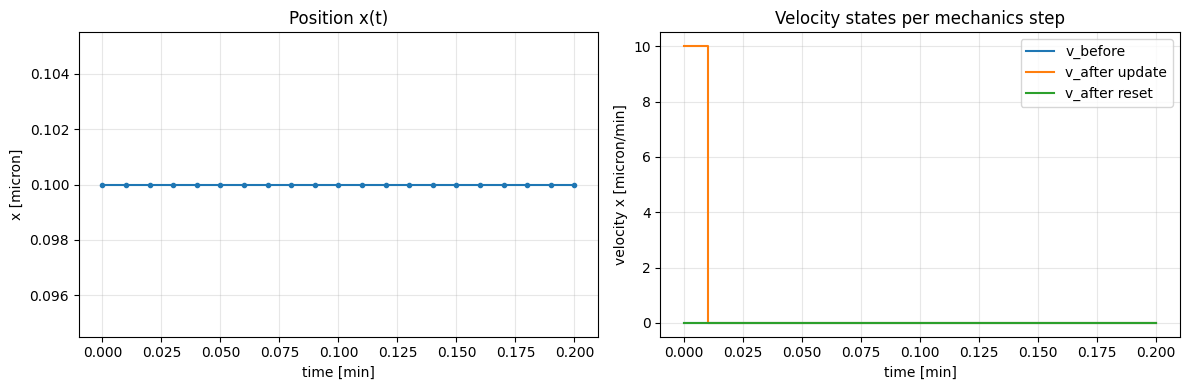

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(df['t'], df['x_x'], marker='o', ms=3)
ax[0].set_title('Position x(t)')
ax[0].set_xlabel('time [min]')
ax[0].set_ylabel('x [micron]')
ax[0].grid(True, alpha=0.3)

ax[1].step(df['t'], df['v_before_x'], where='post', label='v_before')
ax[1].step(df['t'], df['v_after_x'], where='post', label='v_after update')
ax[1].step(df['t'], df['v_after_reset_x'], where='post', label='v_after reset')
ax[1].set_title('Velocity states per mechanics step')
ax[1].set_xlabel('time [min]')
ax[1].set_ylabel('velocity x [micron/min]')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()

## Interpretation

This analytical reconstruction confirms the implemented logic in `custom.cpp`:

- First mechanics step uses a motility pulse (`speed=10`) with `previous_velocity` warm-started to 10.
- Therefore, first-step displacement is exactly $dt dot 10$ (not $1.5dtdot 10$).
- From the next step onward, motility and both velocity states are forced to zero, so position remains constant.

This is fully consistent with PhysiCell's standard velocity update and Adams–Bashforth position integration order.